In [ ]:
## 3) Atividade Práticas Experimentais


In [ ]:
## 3.1 - Correção de Ponto Branco (White Point Correction)

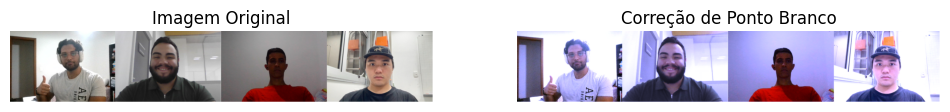

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Garantindo que a função de plotagem existe nesta célula
def mostrar_comparacao(img1, img2, titulo1, titulo2, cmap1=None, cmap2=None):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    if cmap1: plt.imshow(img1, cmap=cmap1)
    else: plt.imshow(img1)
    plt.title(titulo1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    if cmap2: plt.imshow(img2, cmap=cmap2)
    else: plt.imshow(img2)
    plt.title(titulo2)
    plt.axis('off')
    plt.show()

# 2. Função de Correção de Ponto Branco [cite: 17]
def white_point_correction(img, sourcewp, targetwp):
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)

# 3. Carregando a imagem de forma segura (Substitua 'sua_foto_aqui.jpg' pelo nome correto!)
img_bgr = cv2.imread('imagem_grupo.png') 

if img_bgr is None:
    print("ERRO: A imagem não foi encontrada! Verifique se o nome do arquivo está correto e na mesma pasta.")
else:
    # Converte para RGB e normaliza para a escala [0, 1]
    img_grupo_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_grupo_norm = img_grupo_rgb / 255.0

    # Definindo pontos brancos hipotéticos (ex: corrigindo luz quente para neutra)
    source_wp = np.array([0.8, 0.8, 0.5]) 
    target_wp = np.array([1.0, 1.0, 1.0]) 

    # Aplicando a correção
    img_wp_corrigida = white_point_correction(img_grupo_norm, source_wp, target_wp)

    # Mostrando o resultado
    mostrar_comparacao(img_grupo_norm, img_wp_corrigida, 
                       'Imagem Original', 'Correção de Ponto Branco')

In [ ]:
## 3.2 - Transformação XYZ para RGB e Correção Gama

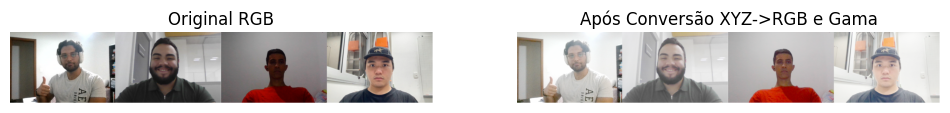

In [4]:
def xyz_to_rgb_gamma(xyz_img):
    # Matriz de conversão linear XYZ para RGB (D65)
    matrix = np.array([[3.2406, -1.5372, -0.4986],
                       [-0.9689, 1.8758, 0.0415],
                       [0.0557, -0.2040, 1.0570]])

    rgb_linear = xyz_img @ matrix.T
    rgb_linear = np.clip(rgb_linear, 0, 1)

    # Correção Gama padrão sRGB
    gamma_corrected = np.where(rgb_linear <= 0.0031308,
                               12.92 * rgb_linear,
                               1.055 * np.power(rgb_linear, 1/2.4) - 0.055)
    return gamma_corrected

# Convertendo a imagem RGB do grupo para XYZ float32
img_float32 = img_grupo_norm.astype(np.float32)
img_xyz = cv2.cvtColor(img_float32, cv2.COLOR_RGB2XYZ)

# Aplicando a conversão e correção gama
img_gama_corrigida = xyz_to_rgb_gamma(img_xyz)

mostrar_comparacao(img_grupo_norm, img_gama_corrigida, 
                   'Original RGB', 'Após Conversão XYZ->RGB e Gama')

In [ ]:
## 3.3 - O Modelo CIELAB

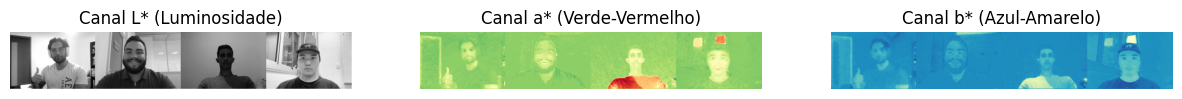

In [ ]:
# Convertendo para LAB usando a variável 'img_bgr' que já foi lida pelo imread nas células anteriores
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
l_chan, a_chan, b_chan = cv2.split(img_lab)

# Plotando os canais separadamente
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(l_chan, cmap='gray'), plt.title('Canal L* (Luminosidade)')
plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(a_chan, cmap='RdYlGn_r'), plt.title('Canal a* (Verde-Vermelho)')
plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(b_chan, cmap='YlGnBu_r'), plt.title('Canal b* (Azul-Amarelo)')
plt.axis('off')
plt.show()

In [ ]:
## 3.4 - Cores Dependentes de Câmera: HSV e sRGB

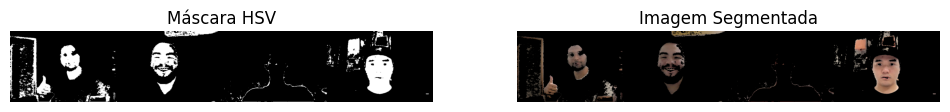

In [10]:
# Convertendo para HSV (Corrigido para img_bgr)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Exemplo didático: Criando uma máscara para tons de pele/vermelho/laranja
# (Ajuste os valores de lower e upper dependendo da iluminação da foto!)
lower_color = np.array([0, 30, 60])
upper_color = np.array([20, 150, 255])

mask_hsv = cv2.inRange(img_hsv, lower_color, upper_color)
segmentado_hsv = cv2.bitwise_and(img_grupo_rgb, img_grupo_rgb, mask=mask_hsv)

mostrar_comparacao(mask_hsv, segmentado_hsv, 
                   'Máscara HSV', 'Imagem Segmentada', cmap1='gray')

In [ ]:
## 3.5 - Modelo YCbCr

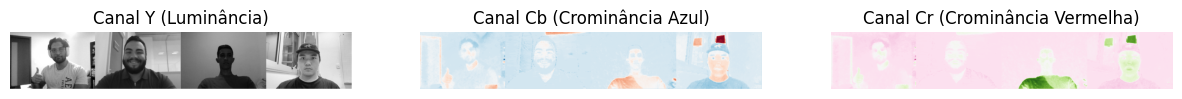

In [11]:
def rgb_to_ycbcr(rgb_img):
    # Coeficientes da transformação BT.601
    transform_mat = np.array([[0.299, 0.587, 0.114],
                              [-0.1687, -0.3313, 0.5],
                              [0.5, -0.4187, -0.0813]])
    ycbcr = rgb_img @ transform_mat.T
    ycbcr[:,:,1:] += 0.5 # Ajuste de offset para Cb e Cr
    return np.clip(ycbcr, 0, 1)

# Aplicando a transformação na imagem normalizada
img_ycbcr_manual = rgb_to_ycbcr(img_grupo_norm)

Y_ch = img_ycbcr_manual[:, :, 0]
Cb_ch = img_ycbcr_manual[:, :, 1]
Cr_ch = img_ycbcr_manual[:, :, 2]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(Y_ch, cmap='gray'), plt.title('Canal Y (Luminância)')
plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(Cb_ch, cmap='RdBu'), plt.title('Canal Cb (Crominância Azul)')
plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(Cr_ch, cmap='PiYG'), plt.title('Canal Cr (Crominância Vermelha)')
plt.axis('off')
plt.show()

In [ ]:
## 3.6 - Correção do ponto branco e gama 

In [2]:
import cv2
import numpy as np

# Funções auxiliares
def white_point_correction(img, sourcewp, targetwp):
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)

def apply_gamma(rgb_linear):
    gamma_corrected = np.where(rgb_linear <= 0.0031308,
                               12.92 * rgb_linear,
                               1.055 * np.power(rgb_linear, 1/2.4) - 0.055)
    return np.clip(gamma_corrected, 0, 1)

# Inicia a captura de vídeo da webcam
cap = cv2.VideoCapture(0)

# --- CONFIGURAÇÃO DA GRAVAÇÃO DE VÍDEO ---
largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = 20.0 # Taxa de quadros por segundo
fourcc = cv2.VideoWriter_fourcc(*'XVID') # Codec de vídeo
# Cria o objeto que vai gravar o vídeo
out = cv2.VideoWriter('3_6_video_demonstrativo.avi', fourcc, fps, (largura, altura))
# -----------------------------------------

modo = 1 
source_wp = np.array([0.7, 0.8, 1.0]) 
target_wp = np.array([1.0, 1.0, 1.0]) 

print("GRAVANDO VÍDEO... Pressione Q para parar e salvar.")
print("Controles: 1 (Original) | 2 (Ponto Branco) | 3 (Gama) | 4 (Ambos)")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Normaliza a imagem
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) / 255.0
    resultado_rgb = img_rgb.copy()

    # Aplica os filtros
    if modo == 2 or modo == 4:
        resultado_rgb = white_point_correction(resultado_rgb, source_wp, target_wp)
    if modo == 3 or modo == 4:
        resultado_rgb = apply_gamma(resultado_rgb)

    # Converte de volta para exibição
    resultado_bgr = cv2.cvtColor((resultado_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

    # Criação do texto na tela
    exibicao = resultado_bgr.copy()
    cv2.putText(exibicao, f"Modo atual: {modo}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    cv2.imshow('3.6 - Gravando Webcam', exibicao)
    
    # SALVA O FRAME ATUAL NO VÍDEO
    out.write(exibicao)

    # Controles de teclado
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('1'): modo = 1
    elif key == ord('2'): modo = 2
    elif key == ord('3'): modo = 3
    elif key == ord('4'): modo = 4

print("Vídeo 3.6 salvo com sucesso!")
cap.release()
out.release() # Finaliza o arquivo de vídeo
cv2.destroyAllWindows()

GRAVANDO VÍDEO... Pressione Q para parar e salvar.
Controles: 1 (Original) | 2 (Ponto Branco) | 3 (Gama) | 4 (Ambos)
Vídeo 3.6 salvo com sucesso!


In [ ]:
## 3.7 - Detecção de Cor pelo Método HSV

In [3]:
import cv2
import numpy as np

def nothing(x):
    pass

cap = cv2.VideoCapture(0)

# --- CONFIGURAÇÃO DA GRAVAÇÃO DE VÍDEO ---
largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = 20.0
fourcc = cv2.VideoWriter_fourcc(*'XVID')
# A largura é multiplicada por 2 porque colocamos as duas imagens lado a lado (hstack)
out = cv2.VideoWriter('3_7_video_demonstrativo.avi', fourcc, fps, (largura * 2, altura))
# -----------------------------------------

cv2.namedWindow('Controles HSV')
cv2.createTrackbar('H Min', 'Controles HSV', 90, 179, nothing) # Começando perto do Azul
cv2.createTrackbar('S Min', 'Controles HSV', 100, 255, nothing)
cv2.createTrackbar('V Min', 'Controles HSV', 50, 255, nothing)
cv2.createTrackbar('H Max', 'Controles HSV', 130, 179, nothing)
cv2.createTrackbar('S Max', 'Controles HSV', 255, 255, nothing)
cv2.createTrackbar('V Max', 'Controles HSV', 255, 255, nothing)

print("GRAVANDO VÍDEO... Pressione Q para parar e salvar.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    h_min = cv2.getTrackbarPos('H Min', 'Controles HSV')
    s_min = cv2.getTrackbarPos('S Min', 'Controles HSV')
    v_min = cv2.getTrackbarPos('V Min', 'Controles HSV')
    h_max = cv2.getTrackbarPos('H Max', 'Controles HSV')
    s_max = cv2.getTrackbarPos('S Max', 'Controles HSV')
    v_max = cv2.getTrackbarPos('V Max', 'Controles HSV')

    lower_color = np.array([h_min, s_min, v_min])
    upper_color = np.array([h_max, s_max, v_max])

    mask = cv2.inRange(hsv, lower_color, upper_color)
    resultado_segmentado = cv2.bitwise_and(frame, frame, mask=mask)

    # Junta as imagens
    tela_dividida = np.hstack((frame, resultado_segmentado))

    cv2.imshow('3.7 - Gravando HSV', tela_dividida)
    
    # SALVA O FRAME DIVIDIDO NO VÍDEO
    out.write(tela_dividida)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

print("Vídeo 3.7 salvo com sucesso!")
cap.release()
out.release() # Finaliza o arquivo de vídeo
cv2.destroyAllWindows()

GRAVANDO VÍDEO... Pressione Q para parar e salvar.
Vídeo 3.7 salvo com sucesso!


In [ ]:
## 4) Exercícios Propostos

In [ ]:
## 4.1 - Comparação de Luminosidade

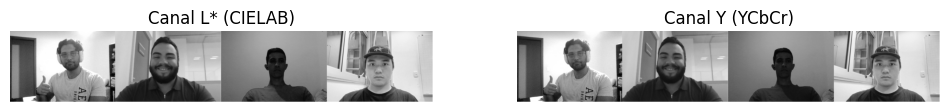

In [5]:
import cv2
import matplotlib.pyplot as plt

# 1. Garantindo que a função de plotagem existe na memória
def mostrar_comparacao(img1, img2, titulo1, titulo2, cmap1=None, cmap2=None):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    if cmap1: plt.imshow(img1, cmap=cmap1)
    else: plt.imshow(img1)
    plt.title(titulo1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    if cmap2: plt.imshow(img2, cmap=cmap2)
    else: plt.imshow(img2)
    plt.title(titulo2)
    plt.axis('off')
    plt.show()

# 2. Carregando a imagem novamente (NÃO ESQUEÇA DE COLOCAR O NOME DA SUA FOTO AQUI)
img_bgr = cv2.imread('imagem_grupo.png')

if img_bgr is None:
    print("ERRO: A imagem não foi encontrada! Verifique se o nome do arquivo está correto e na mesma pasta.")
else:
    # 3. Fazendo as conversões (Exercício 1)
    img_lab_ex1 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
    l_chan_ex1, a_chan, b_chan = cv2.split(img_lab_ex1)

    img_ycbcr_ex1 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    y_chan_ex1, cr_chan, cb_chan = cv2.split(img_ycbcr_ex1)

    # 4. Exibindo o resultado
    mostrar_comparacao(l_chan_ex1, y_chan_ex1, 
                       'Canal L* (CIELAB)', 'Canal Y (YCbCr)', 
                       cmap1='gray', cmap2='gray')

## 4.2 - Efeito Gama:

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

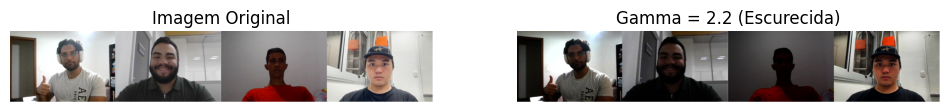

In [2]:

def mostrar_comparacao(img1, img2, titulo1, titulo2):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(titulo1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(titulo2)
    plt.axis('off')
    
    plt.show()

# Carregando imagem
img_bgr = cv2.imread('imagens/imagem_grupo.png')

if img_bgr is None:
    print("ERRO: imagem não encontrada")
else:
    # Convertendo para RGB (pra mostrar certo no matplotlib)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Normalizando (0 a 1)
    img_norm = img_rgb / 255.0

    # Aplicando gama inversa (gamma = 2.2)
    gamma = 2.2
    img_gamma = np.power(img_norm, gamma)

    # Voltando pra 0–255
    img_gamma = (img_gamma * 255).astype(np.uint8)

    # Mostrando resultado
    mostrar_comparacao(img_rgb, img_gamma, 
                       'Imagem Original', 
                       'Gamma = 2.2 (Escurecida)')

## 4.2 -  Filtro de Cor: 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


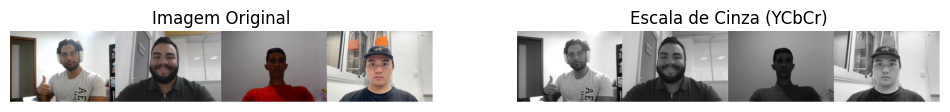

In [4]:

def mostrar_comparacao(img1, img2, titulo1, titulo2):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(titulo1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(titulo2)
    plt.axis('off')
    
    plt.show()

# Carregando imagem
img_bgr = cv2.imread('imagens/imagem_grupo.png')

if img_bgr is None:
    print("ERRO: imagem não encontrada")
else:
    # Convertendo para YCbCr
    img_ycbcr = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)

    # Separando canais
    y, cr, cb = cv2.split(img_ycbcr)

    # Zerando canais de cor
    cr[:] = 128
    cb[:] = 128

    # Reconstruindo imagem
    img_gray_ycbcr = cv2.merge([y, cr, cb])

    # Convertendo de volta pra RGB
    img_result = cv2.cvtColor(img_gray_ycbcr, cv2.COLOR_YCrCb2RGB)

    # Convertendo original pra RGB só pra exibir
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Mostrando
    mostrar_comparacao(img_rgb, img_result, 
                       'Imagem Original', 
                       'Escala de Cinza (YCbCr)')

## 4.4 - O Desafio do Semáforo ou Objeto Colorido

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt



<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Dell G15\AppData\Local\Temp\ipykernel_45004\3126446866.py:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  img_bgr = cv2.imread('imagens\semaforo.png')


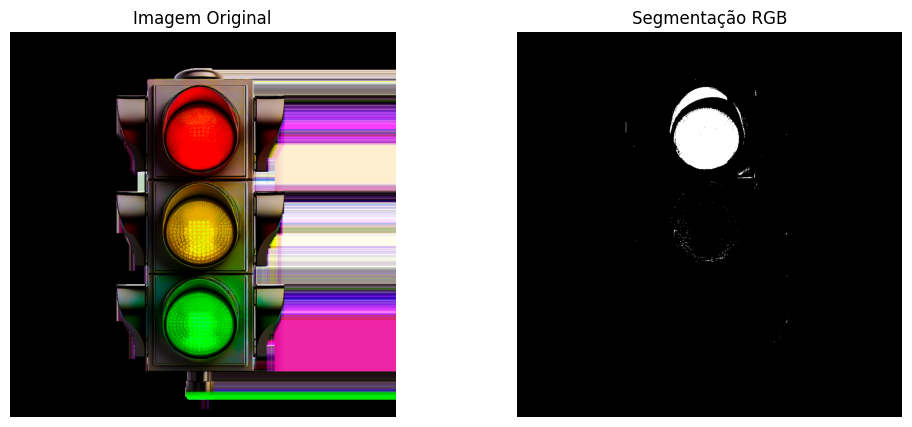

In [8]:
def mostrar_comparacao(img1, img2, titulo1, titulo2):
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title(titulo1)
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(img2, cmap='gray')
    plt.title(titulo2)
    plt.axis('off')
    
    plt.show()

# Carregar imagem
img_bgr = cv2.imread('imagens\semaforo.png')

if img_bgr is None:
    print("Erro ao carregar imagem")
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Definindo limites para vermelho (ajuste conforme sua imagem)
    lower = np.array([150, 0, 0])
    upper = np.array([255, 100, 100])

    # Criando máscara
    mask = cv2.inRange(img_rgb, lower, upper)

    mostrar_comparacao(img_rgb, mask, 
                       'Imagem Original', 
                       'Segmentação RGB')

<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Dell G15\AppData\Local\Temp\ipykernel_45004\1012097118.py:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  img_bgr = cv2.imread('imagens\semaforo.png')


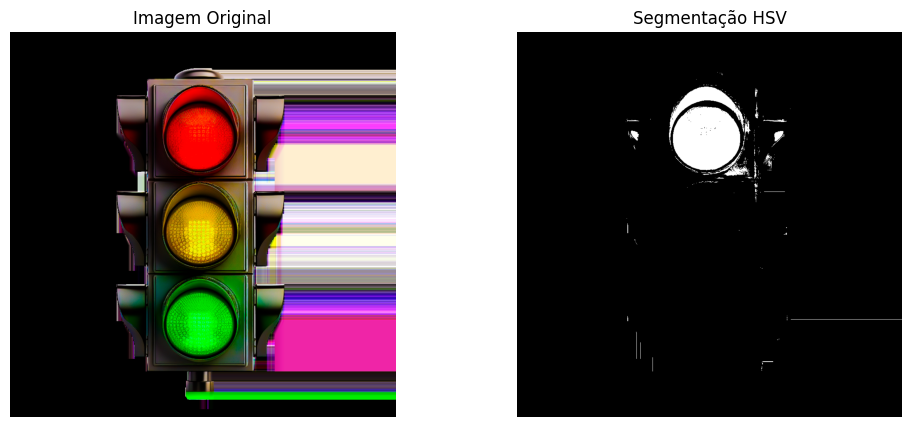

In [9]:
def mostrar_comparacao(img1, img2, titulo1, titulo2):
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title(titulo1)
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(img2, cmap='gray')
    plt.title(titulo2)
    plt.axis('off')
    
    plt.show()

# Carregar imagem
img_bgr = cv2.imread('imagens\semaforo.png')

if img_bgr is None:
    print("Erro ao carregar imagem")
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Vermelho no HSV (tem dois intervalos)
    lower1 = np.array([0, 120, 70])
    upper1 = np.array([10, 255, 255])

    lower2 = np.array([170, 120, 70])
    upper2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(img_hsv, lower1, upper1)
    mask2 = cv2.inRange(img_hsv, lower2, upper2)

    mask = mask1 + mask2

    mostrar_comparacao(img_rgb, mask, 
                       'Imagem Original', 
                       'Segmentação HSV')

##### A segmentação usando HSV foi mais fácil de configurar, porque o canal Hue representa diretamente a cor, então foi mais intuitivo definir os intervalos. Já no RGB, foi mais difícil, pois a cor depende da combinação dos três canais, e pequenas variações de iluminação mudam bastante os valores.

##### Além disso, o HSV lidou melhor com sombras, porque separa a informação de brilho (Value) da cor. No RGB, áreas com sombra acabam tendo valores menores em todos os canais, o que faz o objeto não ser detectado corretamente.

## **a) Ponto Branco e Constância de Cor**

![Image](https://images.openai.com/static-rsc-4/zJpuJJyB-9YDQS27aHEGEYU_6mBlHsOaYWAnIM3xZ_-WRiPeJvZ7rnnNiasSkDpdzmaCBjPXE-LW9MxMW7JiVbMRPtF7QO9_UHD3NVdH53ZLCo74yrsBk6Hl8fnnt_2ZXuigTKfXjyUFXytwg_lbXJrW12TK2IPuYWM_7nQiKnjQPE7bdCjB9O_6UdpxwUvD?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/Xb3NiqE6OlxK1s-oMbixnRQ5RBXeWOKTlieFv8tZhoSEdBcvCE1TL_foxHoSlg0lK9resDLkl3LMb90ZrMzABbW4ZITDZldNfDvYezBJn4-kxsIF8HEfMF52SUUOP0NmDd2FFkDKjAr21uVYek00sjKUdrrFXtEARhbA7vBO-NC6BpoXtbDWa8M8sewglvSq?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/d8hKV52TJBHmAHf1uPgTGWRDMqY_oO4lAoW1P8iMDTcFH-bDLHOVKPHDfkgouoQMkbUru-yK9Uv_r0_e_9FnbUyh0JyJOJ4K88lvQ2c-Baqi5_sAg5t2pSZATOwxnZEV3YD_oNIhNv7y6Bk8T2nfrVupCPy5c0tN-rFcv8cO5OdJGdsk1AtuG2SoM_KuY3RX?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/E5o7hsTM22HSGc1o_kb2L56mAhTT7VP-IvsupHbLMJn1TlWOd_ORR4R3ZSDC3loTCe6f-EkQdKOBU-s2BJv3VpygzfdMRhas4EzMxP1d8VTCku9HGt3whRxFQNFAPKjf9TqsI8_9zWpBsSWcqnOK1yCnzq4SZiSvh0BSa0ZV2jAsqpCNp_k5wopLjWvYQodT?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/NpbwpgfH3ry4A4oe9hBV9AeBuSIOvGGfuGcUsZu08F5piKzGred_nhCIsyV6KWTBr5vs7dpj9PteuA1Z0WTzdjwp0U4R7jpkVVYOj81VW7QOZuiG88E5-78jgJwUhYdSeZi-P46dO3sFivMo5ifQHGXSSyM1uG6Lq4WCXV8NcMJIhqbodbnLfkyEwC6oolcy?purpose=fullsize)

A correção de ponto branco é considerada uma **transformação de adaptação cromática** porque ela tenta ajustar as cores de uma imagem como se tivessem sido observadas sob uma iluminação padrão (geralmente luz branca neutra).

Na prática, isso simula o comportamento do sistema visual humano, que consegue perceber cores de forma relativamente constante mesmo quando a iluminação muda (constância de cor). Assim, a transformação “adapta” os valores de cor para compensar o tom da luz ambiente (amarelada, azulada, etc.), fazendo com que objetos que deveriam ser brancos continuem aparentando branco.

---

## **b) Espaços Independentes vs. Dependentes**

![Image](https://images.openai.com/static-rsc-4/ql2kKhb9c63JdNfycP6JeMs0IzaqCWa6_zLBnaSWUxMbu4x7S3Go5CJXd1qjFJ5bwhFVuDrMv2YGE6RBTwrZGs-qpX5FGz8_IokNbEtJCiOdU_mcSOtcaAExSDuj__iZlQF1ssDWRqSTeSZNZ86rp82tfnKiTqnUX8OqqBcTdw8KeMlu-qWRY7f6MEloXuBQ?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/3CKJuc4FOp3tb0Ed7u9hl4wW660y-IY6CaKKe5r7_QBenEZE95_6RgP9WcEK_33IOgesYX90Jp3WD0TmbOXmc1oFCqNNyoyNLROanJ55BpJ5Edbx7VO8n09CZtkCKU-xRJdOHXLFn75kUwegA_WssnvTtzFbKJ1o0aM2FI3rQMmdzNqoWFTK8GmD_0Z7zk6i?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/9K86nrFgfvRxAPjtik8xclawcPY1LqWPmKaQLxVZY5lrxxJ9U7cfnKdCO_Co3Lm5qhDyFlVk4NxWkNub_SyjhtcE7Vev0vAgeCvSXG0elEnF2-5FqkruzR8nnNK_hQqQxX3_eS2Ms5tT_hPvjtO5zXsrMVCiCe7jx9mfusCN1sB_WXO8_sGyG30SYukUoCQq?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/IEzhHu0KeyywVvKSHul-hmEbO8oIkItQmNy6_htlUiODqsCT5RyQrsLlAFxGfT3YKRVHpV5bvRPeBTAqox_j6HwatyBbzrsN0fZ_Rdzi_ujUGX0ZL46X2lfYF-Fib32-d_gGX98yoRmFlifTrdSp7iVikyvh5tZHGMp05Goc9omiDbV65W9jz_ygTvFcxtof?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/hGEhgWqEboXM-S0C93ReSe_6ThdTtf_B6tTVF28GDIPa9RnqFHrbfRsuZe8XFD-wSc8mOiwNRm1ixQN0T7ZQOJFMYc9DTXSzWf93rrsWle9YmcvmUPfZ3YaAmSU5eKst7ekbAqL95tl-AG9bwaoCnTfra55tQCgadYMcd7zHLTsE2KDVjWF-u3P6KHuxHytT?purpose=fullsize)

A principal diferença prática entre o **CIE XYZ** e o **sRGB** é que:

* O **CIE XYZ** é um espaço **independente de dispositivo**, ou seja, não depende de nenhum monitor específico.
* O **sRGB** é um espaço **dependente de dispositivo**, projetado especificamente para representar cores em monitores, celulares e imagens digitais comuns.

Não exibimos imagens diretamente em XYZ porque os monitores funcionam com **canais RGB físicos (luz vermelha, verde e azul)**. O XYZ é mais teórico e serve como base para conversões entre espaços de cor, mas não corresponde diretamente ao funcionamento do hardware.

---

## **c) Necessidade da Correção Gama**

![Image](https://images.openai.com/static-rsc-4/kt4NgW1-YxDZ5bRZdIc6UjDx_SaROgu2YAV39CwPgzE5urrHgFyNxwVKQVldEoPx69gyBTJkK7RCDLZjLD8ng0PHRkWvUcUr3FfUxdRNqncZyFV8NKPUaG4Z4EphY6DFYY2htH1ATlS_NjGo4tqrL-oV31N_n0xWWmqL895bHPJtDUUIZFtK0pGeKq2zIWiz?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/nJR-gbVoZoCNsb6I6UR537HFSrWqROF4WkfTXOpXG6hT38YjAD6wjKoCt4o4krtdzEAOFp4Xx4Fl21Y8LcFPuFwtIwGKDFc_7GmkVmpuxJ_cCTIuTUAAl4l8mDwDRh7-fKOLICvSDJSUvYJhnAV9PmVUTfXPav4uKpgKxSMV2NFUG3y1wBbz34SSIBKnFJdp?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/CBfEPl8-m8iilhyptwFpd3lnfG0k4laigetAFIIDykwJnQHs8miSd58_ArVQmZBKqP51CD1YiHKV6u1le472xNqPndRZmo16zUTsypCuwj4fHF1kxfzDtmIiN7-8KSQAdiG-r8LHmxCPNupc640l3oaHdsop-X1oRB0pD3n0iJoGSs8xKxY65gG-h2Vf8PqT?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/BkvhU9R1_ITxHn8ut_RMWCgjx8JHslfrnRVF14HcQVCR_8TEzlDHTb1HQQlVlpCxNBfbSV2OOAcdkk90buj5ZN_t4eAaGJ9QdG8vqkhMaBPWHyWG9hCbWh7mo78x_g18oYJaHnxolnXUXtMZeu91YJQ4fkO6yIMt07vzdKxEoFsLXovYREnnuFou1fINFWea?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/wl7Eg6KfoJaXObxoe-4H00WajBMkDv3jMJ_jrrD_pAGyTJlyP3qrho9Fs6YU7hEr94fazGkzmDcHVuuubEh7HgeocMLmFUCFTCnAXNBN1EiGiI17VeYmungGprm7itHUE-3qqeSNmkVlRbIsPra1l1dQaYgGbPREPIX9_obx5tZNk41e10AtTsMywexZt2OD?purpose=fullsize)

Se a correção gama fosse omitida, a imagem seria exibida de forma **linear**, o que não corresponde à forma como o olho humano percebe a luz.

Na prática, isso causaria:

* Perda de detalhes nas sombras
* Regiões escuras ficariam “achatadas” ou quase totalmente pretas

Isso acontece porque o olho humano é mais sensível a variações em regiões escuras, e a correção gama ajusta a imagem justamente para preservar esses detalhes perceptuais.

---

## **d) Percepção Humana e o Modelo CIELAB**

![Image](https://images.openai.com/static-rsc-4/Rxd5chNk51cOpPVHp27p8XigrptwMrYACQ5ZE8GVdxKxEHmQU9x0RUOlM092VxJjj6E0SNu2lbTjpwaJFqHHdF9ONZ2r1OmrwN4VRsFFHoFBi2y5jj7y2OCKeQ-yak-U_am6SS7idMF1OIvkL9M8-ciw9ju3HiZ25RxjTqdzCqqONZ7nAJ0vffSKX3LFG3bm?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/KSL1Tt2eAJejBc7ZYt9tM-vc92EuEHxz7A_Q1xivvXu6QaEyO0aRUmJoQA_jHMt5lmxy-E85monZnfbNuad7w0Sw9ldSGRVhNkT39sCDiXyTfJKL0pJwgbs5S9EYN7sDaljaWvp58GHXwJ7bhuh9iqVatmtqyCM2lppK_ph8AwD8njI3ZkFLKck4iWFRsly6?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/lJ0kLvAWkJgO6uND9AX9R_IYZfiG0Lzg6df4YZ57o2KeEfgA56DQgdsT_vhPzpWyCnzPEEbJn3BBHi0u7hDPwYQ8emZx47rcFGWQpmYTzm_AP8rYkoJnXiTwx9lE6gTKS8qgmeYh_FjVgEf0Lg_IewbSIvNZOj3QxNyOgVmehGgeZGwys0wGbjidAfIu0XQb?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/kZnqRQ_zLnzXwynfUkh-lJ38ab7Tj8ezbUU2Cg7CORtOjrBeN8GSV2Kx3oXkWkgAUjqFtuxC0fFfa26rzDQ1vUcyhyClEj9qhf9t5g5tGW6aSHh4nWap4s_iA-cGUJf2HZ-uFYfkjfjHWHio5prM9X1VuRY4vfITt1ResY-C1rLnh5sy7VAE3KV1EDoJleNq?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/5fz_qc7rlym_hfqDLpjLQUYoEEG_ojU74Livdl76DbUOr_y9brRR6DQ2YXKHF0YT1lfiBWYv4k4PbLXMtjKAbhVxfiG0P1pPpmzhFwZBhdYDI-HLx5MQQ905abWuAe-ytE0lJSiCVnI18xho9f4THfaa7X8Pf83spktx-pdK1iXNtatF6QrMlVZgHJIq2Oq8?purpose=fullsize)

Dizer que o modelo **L*a*b*** é **perceptualmente uniforme** significa que:

👉 **Distâncias iguais no espaço de cor correspondem a diferenças visuais iguais para o ser humano.**

Ou seja, se duas cores estão a uma certa distância no espaço L*a*b*, essa distância representa o quanto elas parecem diferentes para o olho humano.

Isso não acontece em RGB, onde pequenas mudanças numéricas podem não corresponder à mesma percepção visual.

---

## **e) Engenharia de Vídeo e YCbCr**

![Image](https://images.openai.com/static-rsc-4/mVM0Fbhdlpe4w3SwECOiu9Je7FvslEwXj6HGcoc_6att9QXGb-bW-sbtDP1zE24jw_6ao-LXdW2mDwpypuvzZqXYxBgNOpgHj1pVzUxy8Kt-AbB3DM1HGxHLyb-Engl43ikcHZ2rzr8JRl33tIvkzDULFDnWm-xBUyirdwTCQ2YdzzyBQkaxuYeqlhP0U5HC?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/YWjEy5MKrH3RTMieUJx7b1FRBCCdyfHWtJUI0B1txL-jMZehrVLq1XEbq8jfL5NpvA-ERRGh7RKFJ_U285Ewe7Vf9D12dZ0IuQvFMsBY6vJ8U6oXeiabrMZd9F43VFg_5G-qu0z5SrpZNG0D_sIWYJ_uX4aj6SAb1kHPlXnZrqdcY-Tk1t7tv4yo6GzeT7_u?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/dnPio1_EUjbYsmlr4pkxuHNBuTpNNRPhw5FKQIshN9wabBuIFg8K8R8KNkh-dqDZjNRgGokSnVJHFvy56z-Ey8ReUbp8__tyBIhs4nYjO6Nk-ozJEa0utoqTaegqr91_vXHH5HSqRrjswGCTRWK4wb5DUy55QItbl23H1IqOgG92w7TbHILsGZxpK-LKAdiX?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/4MOYFbVN8fBldKCNRpDpxJF0hFVCfXjNlqSkLlHwMsxyHy3DZc_u8WzEI_ZyxSHRygOu9Af2ef1vveoZB9jIC0CHJ6VqEPLotQfLoH4o8n_S7iPfdZwYJh58VLoVL2c93pgqJwX5HWSVVqE-SeImI4QOr9kUuBALndZV8dx_arWX0dTSu9X9SslA9K9eEjjN?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/p64CVTI9AXwwp_wEIdPjPc3ZcJSQnHudFZ1qX_DdT0uQdF44jTMAmVq6WAv9bOXhAXbYk9_Zvcyk8CcVFl0vyTM-pRCAVbrcVghEnvaahYzXkMSTrqvXlQzJ6LAFKigzFHVwWo70xGPdKJlKQ0XJpF9NVH0kWttUcOypAkZCAUG0DqNUOCldWzF2j6cYzCHg?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/JfBRc5jwwIiNL_XtigWeLq8SJuXm521dfK94MCPLsNJxAvwscxBPtZYJW2oU-tHCBusEO3z1NaZZEefDq0wQElOLZNSxUjaW9MbCgpsRcc0Y_NXpbVj9u4gxqEzwycwCcZMyw0erqsxhXJARVqFiz4KmCyBOubm78rhSIE97suJdGte-QC0l8BjX3yD671_O?purpose=fullsize)

Os canais **Cb** e **Cr** parecem mais “borrados” porque representam **informação de cor (crominância)**, enquanto o canal **Y** representa **luminosidade**.

A compressão de vídeo (como JPEG e MPEG) explora isso usando uma técnica chamada **subamostragem de crominância**, onde:

* O canal Y é mantido com alta qualidade
* Os canais Cb e Cr são reduzidos (menos resolução)

Como o olho humano é mais sensível à luz do que à cor, essa redução quase não é percebida visualmente, mas diminui bastante o tamanho do arquivo.

---

## **f) Representação Cilíndrica e Robustez (HSV)**

![Image](https://images.openai.com/static-rsc-4/fwqtWl2FitnHs_oYswRhO5wHTSCHUOO5ZkkKMzGsNhnptQZaRBNj-IkISbTRjkv-3pcG5yL2WPDI3M-hVcgqgxNNIE0d69wgSlfzuYmsU9lE4hHrUxiNlKomAnZ4quGL1e2HVEd5goCTw0t5aC76USnvHsEoyLG1Z8c0Yk9AeUh-aUtDQiZJAweqzBs0gVmZ?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/WVibbWkJRIjSOwH3XVPwR3DzQiOXiGSa4S6trJOl_9_1P3nFKU0jpBhyPPkWx6W9rK-i8nkgdJ5evdKzTkZGVI5cmqw6w0NRhxEPaNsPI2lgb4eu1xoHx5JG5ubh39CL8R0OXU_ySJyMj1EiytKnClDzh-p7eIIquZ6NU9epuUwWuCGJidIwb972D4ctlOEc?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/_E4eS9cHrwZXLG2R3NjRQOvm0xVpgYcOAb0-7jZmd3RGA3vx0cipalSAwO7UBwNaWdszxdrhvdfp7cQnyzKmHQt2ve4HGnNNcz9ue6U7Tj_6pttB0ErafQbdeoLS60shKhzUAyyXq9XENvpv6LTj2WGI3VXeLCIwpnl8onLLlmpz57stE-i3GnVdCnHNGMXQ?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/Gr0s1kAV3kdQpU7YTNSycbXyJhMOmLVw76Urwwm8R0fEaf_VgfLBTrYoSf8whlhi8-D7sBiy4lrLWYuxdaMWHnTQNHNEDweU16CDvhfzewTTwSpG3pv8xRkwsbG2ILwErU6JOO4thJVHfhZM8tgyg1YnSRG3NsVqHRkk07kxOaCgg8OX2KvTth8BZuyA4ujA?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/SNguFwXn541tGtvn-auT5rKapwDD65E0a27wd1SGviaA2N5NAHA0dqCVwnIa07qOxVlfueqKpbsLAi-Koqi0oL5QyLx6MZn0KKiBRE8t83fJ-gDlXbwShLpGGM9C6WgPAKrZ4vj10oNNPA2LlXo68izzne04LrmG1lOZYvxuZ_NZjUQXdeSKGZLnRBEuS9cG?purpose=fullsize)

O canal **H (Hue)** do HSV é preferido porque ele representa **apenas a cor**, separado da iluminação.

Em situações com sombras ou reflexos:

* No **RGB**, os valores mudam bastante (todos os canais são afetados pela luz)
* No **HSV**, o Hue tende a permanecer relativamente estável

Isso torna a segmentação mais robusta, pois conseguimos identificar a cor mesmo com variações de brilho (Value) ou intensidade.

👉 Em resumo:
O HSV funciona melhor porque separa **cor (H)** de **iluminação (V)**, enquanto o RGB mistura tudo, dificultando a análise.


**Resposta (Exercício 1):**
O canal **$L$ (CIELAB)** preserva melhor os detalhes de sombreamento de forma alinhada à percepção original. Isso ocorre porque o espaço CIELAB foi projetado para ser perceptualmente uniforme em relação à visão humana. Já o canal $Y$ (Luminância do YCbCr) é uma combinação linear simples dos canais RGB otimizada para transmissão e compressão de vídeo, e não estritamente para a percepção humana de brilho e contraste.